In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import seaborn as sns
import os
from skimage.io import imread
from skimage.transform import resize
import tensorflow as tf
from tensorflow.keras import layers,models 
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import image_dataset_from_directory

In [2]:
os.listdir(r"D:\Soft\Projects\Deep Learning CNN\Plant Disease\Dataset\Train\train")

['Apple Cedar-apple rust',
 'Apple-Black rot',
 'Apple-healthy',
 'Apple-scab',
 'Blueberry-healthy',
 'Cherry (including_sour)-healthy',
 'Cherry (including_sour)-Powdery mildew',
 'Corn (maize)-Common rust',
 'Corn (maize)-Gray leaf spot',
 'Corn (maize)-healthy',
 'Corn (maize)-Northern Leaf Blight',
 'Grape-Black rot',
 'Grape-Esca (Black Measles)',
 'Grape-healthy',
 'Grape-Leaf blight (Isariopsis Leaf Spot)',
 'Orange-Haunglongbing',
 'Peach-Bacterial spot',
 'Peach-healthy',
 'Pepper bell-Bacterial spot',
 'Pepper bell-healthy',
 'Potato-Early blight',
 'Potato-healthy',
 'Potato-Late blight',
 'Raspberry-healthy',
 'Soybean-healthy',
 'Squash-Powdery mildew',
 'Strawberry-healthy',
 'Strawberry-Leaf scorch',
 'Tomato-Bacterial spot',
 'Tomato-Early blight',
 'Tomato-healthy',
 'Tomato-Late blight',
 'Tomato-Leaf Mold',
 'Tomato-Septoria leaf spot',
 'Tomato-Spider mites Two spotted spider mite',
 'Tomato-Target Spot',
 'Tomato-Tomato mosaic virus',
 'Tomato-Tomato Yellow Leaf C

In [3]:
train_dir=r"D:\Soft\Projects\Deep Learning CNN\Plant Disease\Dataset\Train\train"
valid_dir=r"D:\Soft\Projects\Deep Learning CNN\Plant Disease\Dataset\Train\valid"

In [4]:
train_ds=image_dataset_from_directory(train_dir,image_size=(150,150),batch_size=32,shuffle=True)

Found 70295 files belonging to 38 classes.


In [5]:
valid_ds=image_dataset_from_directory(valid_dir,image_size=(150,150),batch_size=32,shuffle=False)

Found 17572 files belonging to 38 classes.


In [6]:
class_names=train_ds.class_names

print(len(class_names))
print(class_names)

38
['Apple Cedar-apple rust', 'Apple-Black rot', 'Apple-healthy', 'Apple-scab', 'Blueberry-healthy', 'Cherry (including_sour)-Powdery mildew', 'Cherry (including_sour)-healthy', 'Corn (maize)-Common rust', 'Corn (maize)-Gray leaf spot', 'Corn (maize)-Northern Leaf Blight', 'Corn (maize)-healthy', 'Grape-Black rot', 'Grape-Esca (Black Measles)', 'Grape-Leaf blight (Isariopsis Leaf Spot)', 'Grape-healthy', 'Orange-Haunglongbing', 'Peach-Bacterial spot', 'Peach-healthy', 'Pepper bell-Bacterial spot', 'Pepper bell-healthy', 'Potato-Early blight', 'Potato-Late blight', 'Potato-healthy', 'Raspberry-healthy', 'Soybean-healthy', 'Squash-Powdery mildew', 'Strawberry-Leaf scorch', 'Strawberry-healthy', 'Tomato-Bacterial spot', 'Tomato-Early blight', 'Tomato-Late blight', 'Tomato-Leaf Mold', 'Tomato-Septoria leaf spot', 'Tomato-Spider mites Two spotted spider mite', 'Tomato-Target Spot', 'Tomato-Tomato Yellow Leaf Curl Virus', 'Tomato-Tomato mosaic virus', 'Tomato-healthy']


In [7]:
pickle.dump(class_names,open("class_names.pkl","wb"))

In [8]:
normalization_layer=layers.Rescaling(1./255)
train_ds=train_ds.map(lambda x,y:(normalization_layer(x),y))
valid_ds=valid_ds.map(lambda x,y:(normalization_layer(x),y))

In [9]:
AUTOTUNE=tf.data.AUTOTUNE
train_ds=train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds=valid_ds.prefetch(buffer_size=AUTOTUNE) 

In [ ]:
model=Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(150,150,3)))
model.add(MaxPool2D(2,2))
model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPool2D(2,2))
model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPool2D(2,2))
model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dense(38,activation="softmax"))

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,499,764 (55.31 MB)

 Trainable params: 4,833,254 (18.44 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,666,510 (36.87 MB)

In [16]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [35]:
model.fit(train_ds,validation_data=valid_ds,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1237s 562ms/step - accuracy: 0.7108 - loss: 0.9689 - val_accuracy: 0.8352 - val_loss: 0.5259
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1208s 550ms/step - accuracy: 0.9057 - loss: 0.2922 - val_accuracy: 0.9001 - val_loss: 0.3151
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1997s 909ms/step - accuracy: 0.9427 - loss: 0.1719 - val_accuracy: 0.9076 - val_loss: 0.3340
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1002s 456ms/step - accuracy: 0.9602 - loss: 0.1183 - val_accuracy: 0.9140 - val_loss: 0.3079
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 972s 442ms/step - accuracy: 0.9705 - loss: 0.0884 - val_accuracy: 0.9274 - val_loss: 0.2806
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 832s 378ms/step - accuracy: 0.9745 - loss: 0.0765 - val_accuracy: 0.9246 - val_loss: 0.3004
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 853s 388ms/step - accuracy: 0.9793 - loss: 0.0639 - val_accuracy: 0.9325 - val_loss: 0.2951
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 823s 374ms/step 

In [ ]:
val_loss,val_acc=model.evaluate(valid_ds)

550/550 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.9389 - loss: 0.2886
0.28858980536460876 0.9388800263404846


In [50]:
print("Validation Accuracy:",val_acc*100)
print("Validation Loss:",val_loss*100)

Validation Accuracy: 93.88800263404846
Validation Loss: 28.858980536460876


In [ ]:
model.save("plant_disease_model.keras")

In [14]:
model=load_model("plant_disease_model.keras")

In [48]:
img=imread(r"D:\Soft\Projects\Deep Learning CNN\Plant Disease\Dataset\Test\AppleScab.JPG")

In [49]:
img=resize(img,(150,150,3))

In [50]:
print(img.min())
print(img.max())

0.018763050860162635
0.7603090409019546


In [51]:
img=img.reshape(1,150,150,3)
print(img.shape)

(1, 150, 150, 3)


In [53]:
p=model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [54]:
p_class=class_names[np.argmax(p)]

In [55]:
print("Detected Disease :",p_class)

Detected Disease : Apple-scab


In [56]:
confidence=np.max(p)*100
print("Confidence:",confidence)

Confidence: 99.91309


In [57]:
img1=imread(r"D:\Soft\Projects\Deep Learning CNN\Plant Disease\Dataset\Test\TomatoHealthy4.JPG")
img1=resize(img1,(150,150,3))
img1=img1.reshape(1,150,150,3)

In [58]:
p1=model.predict(img1)
p1_class=class_names[np.argmax(p1)]
print("Detected Disease :",p1_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


Detected Disease : Tomato-healthy


In [59]:
img2=imread(r"D:\Soft\Projects\Deep Learning CNN\Plant Disease\Dataset\Test\TomatoYellowCurlVirus3.JPG")
img2=resize(img2,(150,150,3))
img2=img2.reshape(1,150,150,3)
p2=model.predict(img2)
p2_class=class_names[np.argmax(p2)]
print("Detected Disease :",p2_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Detected Disease : Tomato-Tomato Yellow Leaf Curl Virus


In [60]:
def prediction(path):
    img=imread(path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    img=resize(img,(150,150,3))
    img=img.reshape(1,150,150,3)
    p=model.predict(img)
    p_class=class_names[np.argmax(p)]
    print("Detected Disease :",p_class)
    print("confidence score :",round(np.max(p)*100,2),"%")    

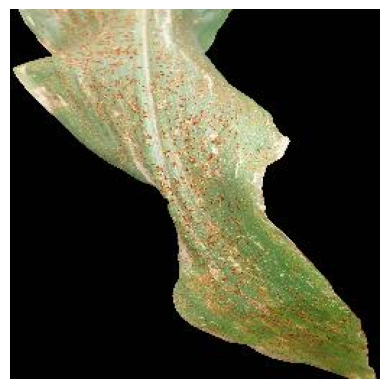

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Detected Disease : Corn (maize)-Common rust
confidence score : 100.0 %


In [61]:
path1=r"D:\Soft\Projects\Deep Learning CNN\Plant Disease\Dataset\Test\CornCommonRust3.JPG"
prediction(path1)

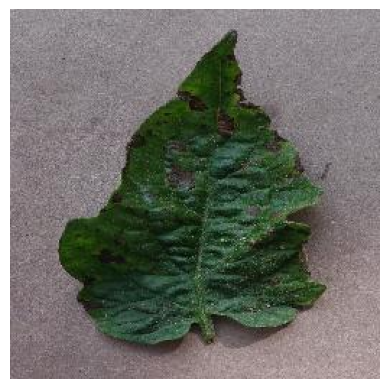

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Detected Disease : Tomato-Early blight
confidence score : 58.61 %


In [62]:
path2=r"D:\Soft\Projects\Deep Learning CNN\Plant Disease\Dataset\Test\TomatoEarlyBlight3.JPG"
prediction(path2)

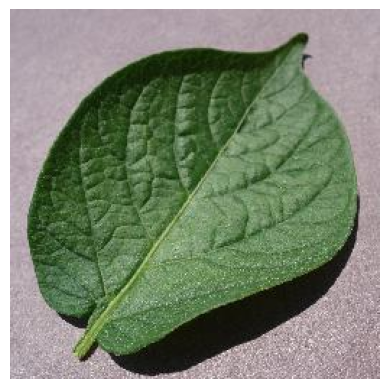

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Detected Disease : Potato-healthy
confidence score : 100.0 %


In [63]:
path3=r"D:\Soft\Projects\Deep Learning CNN\Plant Disease\Dataset\Test\PotatoHealthy2.JPG"
prediction(path3)